# Evaluation: paper-style aggregate throughput (Fig.7-like)

- **X**: experiment time (s)
- **Y**: **aggregate throughput** (Mbps), one line per algorithm (LIA / OLIA / ...)
- **Preferred source**: `[m]monitor bw=` (instantaneous), fallback to `path :* mean tp`
- **Background bands**: 3 phases from `tc_bw_*.log` (e.g. 0-50, 50-100, 100+)
- **In-band text**: link setting annotations (capacity / delay / loss)
- **Extra (last code cell)**: per-path time series + **steady-window means** from `parse_logs.phase_steady_windows_from_tc_bw` (10 s transition, CSV in `derived/`)

Set `RUN_DIR` / `METHOD_RUNS` in the config cell, then **Run all**.

In [1]:
import os
import re
import sys
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def find_repo() -> Path:
    """Cwd or parents until scripts/analyze/parse_logs.py exists."""
    start = Path.cwd().resolve()
    for p in [start, *start.parents]:
        if (p / "scripts" / "analyze" / "parse_logs.py").is_file():
            return p
    return start


REPO = find_repo()
sys.path.insert(0, str(REPO / "scripts" / "analyze"))
import parse_logs as pl  # noqa: E402

print("REPO =", REPO)

REPO = /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment


In [2]:
# --- run directory (one vm_run folder with pull + tc_bw) ---
RUN_DIR = REPO / "logs_exp" / "log" / "vm_run_20260426_042103"  # <- change to run

# One method → one run dir. Keep in sync with RUN_DIR to avoid stale kernel state.
METHOD_RUNS = {
    "ACCEss-T": RUN_DIR,
}

PULL = next(RUN_DIR.glob("pull_*.log"), None)
TC_BW = next(RUN_DIR.glob("tc_bw_*.log"), None)
assert PULL and TC_BW, f"Need pull_*.log and tc_bw_*.log under {RUN_DIR}"
PULL, TC_BW

(PosixPath('/Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/log/vm_run_20260426_042103/pull_20260426_042103.log'),
 PosixPath('/Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/logs_exp/log/vm_run_20260426_042103/tc_bw_20260426_042103.log'))

In [3]:
from typing import Optional

_RE_MEAN_TP = re.compile(
    r"^(?P<date>\d{4}/\d{2}/\d{2}) (?P<time>\d{2}:\d{2}:\d{2}) path :(?P<path>\d) mean tp: (?P<tp>[\d.]+)Mbps"
)


def load_total_tp_from_mean(pull_path: Path) -> pd.DataFrame:
    """Fallback: sum(path mean tp) per timestamp from pull log."""
    rows: list[dict] = []
    t0: Optional[float] = None
    with open(pull_path, encoding="utf-8", errors="replace") as f:
        for line in f:
            m = _RE_MEAN_TP.match(line)
            if not m:
                continue
            try:
                tp = float(m["tp"])
            except ValueError:
                continue
            if not (tp == tp) or tp < 0:
                continue
            dt = datetime.strptime(m["date"] + " " + m["time"], "%Y/%m/%d %H:%M:%S")
            ts = dt.timestamp()
            if t0 is None:
                t0 = ts
            rows.append({"t_sec": ts - t0, "tp_mbps": tp})
    if not rows:
        return pd.DataFrame(columns=["t_sec", "tp_mbps_total", "source"])
    d = pd.DataFrame(rows)
    out = d.groupby("t_sec", as_index=False)["tp_mbps"].sum().rename(columns={"tp_mbps": "tp_mbps_total"})
    out["source"] = "mean_tp"
    return out


def load_total_tp_from_monitor(pull_path: Path, label: str = "") -> pd.DataFrame:
    """Preferred: sum monitor bw_bytes across paths, converted to Mbps."""
    _u, mon = pl.load_pull_log(pull_path, label=label)
    if mon.empty or "bw_bytes" not in mon.columns:
        return pd.DataFrame(columns=["t_sec", "tp_mbps_total", "source"])
    d = mon[["t", "bw_bytes"]].copy()
    d = d[d["bw_bytes"].notna()]
    if d.empty:
        return pd.DataFrame(columns=["t_sec", "tp_mbps_total", "source"])
    out = d.groupby("t", as_index=False)["bw_bytes"].sum().rename(columns={"t": "t_sec"})
    out["tp_mbps_total"] = out["bw_bytes"] * 8.0 / 1e6
    out = out[["t_sec", "tp_mbps_total"]].sort_values("t_sec").reset_index(drop=True)
    out["source"] = "monitor_bw"
    return out


def load_method_series(run_dir: Path, label: str) -> tuple[pd.DataFrame, Path, Path]:
    pull = next(run_dir.glob("pull_*.log"), None)
    tc_bw = next(run_dir.glob("tc_bw_*.log"), None)
    assert pull is not None and tc_bw is not None, f"[{label}] missing pull/tc_bw in {run_dir}"

    ts = load_total_tp_from_monitor(pull, label=label)
    if ts.empty:
        ts = load_total_tp_from_mean(pull)
    assert not ts.empty, f"[{label}] no usable throughput rows in {pull}"
    ts = ts.copy()
    ts["label"] = label
    return ts, pull, tc_bw


def load_per_path_from_mean(pull_path: Path) -> pd.DataFrame:
    """Long-form: t_sec, path, tp_mbps (same t0 as aggregate mean-tp series)."""
    rows: list[dict] = []
    t0: Optional[float] = None
    with open(pull_path, encoding="utf-8", errors="replace") as f:
        for line in f:
            m = _RE_MEAN_TP.match(line)
            if not m:
                continue
            try:
                tp = float(m["tp"])
            except ValueError:
                continue
            if not (tp == tp) or tp < 0:
                continue
            dt = datetime.strptime(m["date"] + " " + m["time"], "%Y/%m/%d %H:%M:%S")
            ts = dt.timestamp()
            if t0 is None:
                t0 = ts
            rows.append(
                {"t_sec": ts - t0, "path": int(m["path"]), "tp_mbps": tp}
            )
    if not rows:
        return pd.DataFrame(columns=["t_sec", "path", "tp_mbps"])
    d = pd.DataFrame(rows)
    return d.groupby(["t_sec", "path"], as_index=False)["tp_mbps"].mean()


def load_per_path_from_monitor(pull_path: Path, label: str = "") -> pd.DataFrame:
    """Long-form: t_sec, path, tp_mbps from [m]monitor bw."""
    _u, mon = pl.load_pull_log(pull_path, label=label)
    if mon.empty or "bw_bytes" not in mon.columns:
        return pd.DataFrame(columns=["t_sec", "path", "tp_mbps"])
    d = mon[["t", "path", "bw_bytes"]].dropna(subset=["bw_bytes"])
    d = d.rename(columns={"t": "t_sec"})
    d["tp_mbps"] = d["bw_bytes"] * 8.0 / 1e6
    return d.groupby(["t_sec", "path"], as_index=False)["tp_mbps"].mean()


def load_per_path_timeseries(pull_path: Path, label: str) -> pd.DataFrame:
    """Match aggregate source: monitor first, else mean-tp per path."""
    p = load_per_path_from_monitor(pull_path, label=label)
    if not p.empty:
        return p
    return load_per_path_from_mean(pull_path)

In [4]:
# --- paper-style controls ---
SMOOTH = 3             # rolling window (samples)
X_MIN = 10.0           # paper-style often starts around 10s
Y_LIM = None           # auto-scale by default; set (25.0, 50.0) for paper-like fixed range

if "METHOD_RUNS" not in globals() or not METHOD_RUNS:
    # Fallback so this cell won't crash if config cell wasn't run yet.
    METHOD_RUNS = {
        "ACCEss-T": REPO / "logs_exp" / "log" / "vm_run_20260426_042103",
    }
    print("[warn] METHOD_RUNS was undefined. Using fallback. Please edit METHOD_RUNS cell for full multi-method plot.")

method_rows = []
method_logs = {}
for label, run_dir in METHOD_RUNS.items():
    ts, pull, tc_bw = load_method_series(run_dir, label)
    if SMOOTH and SMOOTH > 1:
        ts = ts.copy()
        ts["tp_mbps_total"] = ts["tp_mbps_total"].rolling(SMOOTH, min_periods=1).mean()
    method_rows.append(ts)
    method_logs[label] = {"pull": pull, "tc_bw": tc_bw, "source": ts["source"].iloc[0]}

all_ts = pd.concat(method_rows, ignore_index=True)
t_max = float(all_ts["t_sec"].max()) if not all_ts.empty else 0.0
all_ts.head()

,t_sec,tp_mbps_total,source,label
0,0,78.279552,monitor_bw,ACCEss-T
1,1,886.847232,monitor_bw,ACCEss-T
2,2,649.099776,monitor_bw,ACCEss-T
3,3,666.407808,monitor_bw,ACCEss-T
4,4,144.670720,monitor_bw,ACCEss-T


In [5]:
# --- tc steps for background phases (use first method as reference) ---
# Also align all timelines to tc start, so boundaries are at 0/50/100s.
ref_label = list(METHOD_RUNS.keys())[0]
ref_pull = method_logs[ref_label]["pull"]
ref_tc = method_logs[ref_label]["tc_bw"]

tc_df = pl.tc_bw_with_pull_t(ref_tc, ref_pull).sort_values("at_sec").reset_index(drop=True)

if not tc_df.empty and tc_df["t_pull"].notna().any():
    at0 = tc_df[tc_df["at_sec"] == 0]
    tc_t0_pull = float(at0.iloc[0]["t_pull"]) if not at0.empty else float(tc_df["t_pull"].min())
else:
    tc_t0_pull = 0.0

all_ts = all_ts.copy()
all_ts["t_plot"] = all_ts["t_sec"] - tc_t0_pull

tc_df = tc_df.copy()
tc_df["t_plot"] = tc_df["t_pull"] - tc_t0_pull

t_max = float(all_ts["t_plot"].max()) if not all_ts.empty else 0.0
print(f"tc_start_shift = {tc_t0_pull:.3f}s (pull-time -> tc-time)")
tc_df[["at_sec", "t_pull", "t_plot", "bw_mbit", "dev"]]

tc_start_shift = -3.000s (pull-time -> tc-time)


,at_sec,t_pull,t_plot,bw_mbit,dev
0,0,-3.0,0.0,20.0,h1-eth1
1,50,47.0,50.0,30.0,h1-eth1
2,100,97.0,100.0,10.0,h1-eth1


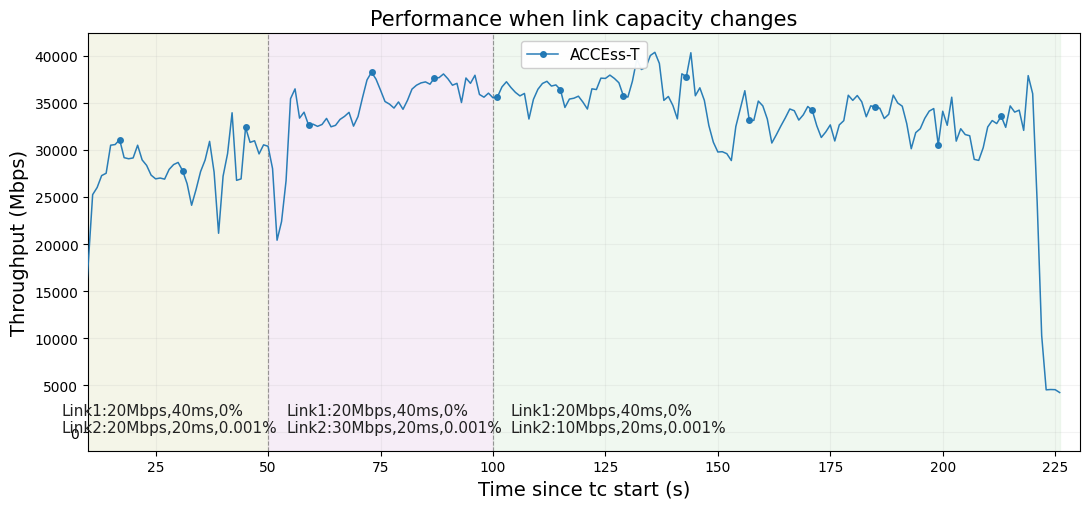

Saved: /Users/jememalum/Project/mpquic/qcurl-4dmap-experiment/derived/evaluation_timeline_notebook.png
Data source per method: {'ACCEss-T': 'monitor_bw'}


In [6]:
fig, ax = plt.subplots(figsize=(11, 5.2))
band_colors = ["#e8eacd", "#ecd9ee", "#dff0df", "#d9e7f7"]

# Optional text in each phase (edit to your exact scenario text)
PHASE_TEXTS = [
    "Link1:20Mbps,40ms,0%\nLink2:20Mbps,20ms,0.001%",
    "Link1:20Mbps,40ms,0%\nLink2:30Mbps,20ms,0.001%",
    "Link1:20Mbps,40ms,0%\nLink2:10Mbps,20ms,0.001%",
]

# Phase shading + step lines (already shifted to tc-start timebase)
segments = []
if not tc_df.empty and tc_df["t_plot"].notna().any():
    n = len(tc_df)
    for i in range(n):
        a = float(tc_df.loc[i, "t_plot"])
        b = float(tc_df.loc[i + 1, "t_plot"]) if i + 1 < n else t_max + 1.0
        b = min(b, t_max + 0.1)
        if b <= a:
            continue
        bw = float(tc_df.loc[i, "bw_mbit"])
        dev = str(tc_df.loc[i, "dev"])
        segments.append((a, b, bw, dev))
        ax.axvspan(a, b, color=band_colors[i % len(band_colors)], alpha=0.45, zorder=0)
        ax.axvline(a, color="#555", ls="--", lw=0.8, alpha=0.6, zorder=1)

for i, (a, b, bw, dev) in enumerate(segments):
    txt = PHASE_TEXTS[i] if i < len(PHASE_TEXTS) else f"{dev}: {bw:.0f}Mbps"
    ax.text(a + 4, (Y_LIM[0] + 5) if Y_LIM else 0.05, txt, fontsize=11, color="#222")

# Multi-method aggregate throughput lines
markers = ["o", "^", "s", "D", "v", "x", "*"]
for i, label in enumerate(METHOD_RUNS.keys()):
    d = all_ts[all_ts["label"] == label].sort_values("t_plot")
    ax.plot(
        d["t_plot"],
        d["tp_mbps_total"],
        label=label,
        lw=1.1,
        marker=markers[i % len(markers)],
        ms=4,
        markevery=max(len(d) // 16, 1),
        alpha=0.95,
        zorder=3,
    )

ax.set_xlabel("Time since tc start (s)", fontsize=14)
ax.set_ylabel("Throughput (Mbps)", fontsize=14)
ax.set_title("Performance when link capacity changes", fontsize=15)
ax.set_xlim(X_MIN, max(t_max * 1.02, X_MIN + 1))
if Y_LIM is not None:
    ax.set_ylim(*Y_LIM)
    y_min = float(all_ts["tp_mbps_total"].min())
    y_max = float(all_ts["tp_mbps_total"].max())
    if y_max < Y_LIM[0] or y_min > Y_LIM[1]:
        print(f"[warn] Data range [{y_min:.3f}, {y_max:.3f}] is outside Y_LIM={Y_LIM}. Set Y_LIM=None to see lines.")
ax.grid(True, alpha=0.15, zorder=2)
ax.legend(loc="upper center", ncol=4, fontsize=11, framealpha=0.95)

fig.tight_layout()
out_png = REPO / "derived" / "evaluation_timeline_notebook.png"
out_png.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_png, dpi=160)
plt.show()
print("Saved:", out_png)
print("Data source per method:", {k: v["source"] for k, v in method_logs.items()})

In [ ]:
# --- Per-path throughput + phase steady means (ref run = first METHOD_RUNS entry) ---
# Requires cells above: method_logs, ref_label, tc_t0_pull, SMOOTH, all_ts, tc_df, t_max (tc-time)

import numpy as np

ref_label = list(METHOD_RUNS.keys())[0]
ref_pull = method_logs[ref_label]["pull"]
ref_tc = method_logs[ref_label]["tc_bw"]
_src = method_logs[ref_label]["source"]

pp_long = load_per_path_timeseries(ref_pull, ref_label)
if pp_long.empty:
    print("No per-path series; check pull log for [m]monitor or mean tp lines.")
else:
    if SMOOTH and SMOOTH > 1:
        pp_long = pp_long.sort_values(["path", "t_sec"])
        pp_long = pp_long.copy()
        pp_long["tp_mbps"] = (
            pp_long.groupby("path")["tp_mbps"]
            .transform(lambda s: s.rolling(SMOOTH, min_periods=1).mean())
        )
    pp_long["t_plot"] = pp_long["t_sec"] - tc_t0_pull

    # ---- Fig A: per-path lines (tc-time) ----
    band_colors = ["#e8eacd", "#ecd9ee", "#dff0df", "#d9e7f7"]
    fig_a, ax_a = plt.subplots(figsize=(11, 4.5))
    if not tc_df.empty and tc_df["t_plot"].notna().any():
        n = len(tc_df)
        for i in range(n):
            a = float(tc_df.loc[i, "t_plot"])
            b = float(tc_df.loc[i + 1, "t_plot"]) if i + 1 < n else t_max + 1.0
            b = min(b, t_max + 0.1)
            if b > a:
                ax_a.axvspan(
                    a, b,
                    color=band_colors[i % len(band_colors)],
                    alpha=0.45,
                    zorder=0,
                )
    for p_id in sorted(pp_long["path"].unique()):
        d = pp_long[pp_long["path"] == p_id].sort_values("t_plot")
        ax_a.plot(
            d["t_plot"],
            d["tp_mbps"],
            label=f"path {p_id}",
            lw=1.0,
            zorder=2,
        )
    if not all_ts.empty and ref_label in all_ts["label"].values:
        tot = all_ts[all_ts["label"] == ref_label].sort_values("t_plot")
        ax_a.plot(
            tot["t_plot"],
            tot["tp_mbps_total"],
            "k--",
            lw=1.0,
            alpha=0.7,
            label="total (same as top figure)",
        )
    ax_a.set_xlabel("Time since tc start (s)")
    ax_a.set_ylabel("Throughput (Mbps)")
    ax_a.set_title(f"Per-path throughput (source={_src}, ref={ref_label})")
    ax_a.set_xlim(X_MIN, max(t_max * 1.02, X_MIN + 1))
    if Y_LIM is not None:
        ax_a.set_ylim(*Y_LIM)
    ax_a.grid(True, alpha=0.15)
    ax_a.legend(loc="upper right", fontsize=9)
    fig_a.tight_layout()
    out_a = REPO / "derived" / "evaluation_per_path_notebook.png"
    out_a.parent.mkdir(parents=True, exist_ok=True)
    fig_a.savefig(out_a, dpi=160)
    plt.show()
    print("Saved:", out_a)

    # ---- Phase steady windows (pull-time) + bar chart of means ----
    _tend = max(220.0, float(all_ts["t_sec"].max()) + 5.0)
    ph = pl.phase_steady_windows_from_tc_bw(
        ref_tc,
        ref_pull,
        transition_sec=10.0,
        experiment_end_sec=_tend,
    )
    print("Steady windows (skip 10s after each tc step):")
    try:
        from IPython.display import display

        display(ph)
    except Exception:
        print(ph)

    rows_mean = []
    for _, r in ph.iterrows():
        pnum = int(r["phase"])
        lo, hi = float(r["t_steady_start"]), float(r["t_steady_end"])
        cap = float(r["bw_mbit"])
        w = (pp_long["t_sec"] >= lo) & (pp_long["t_sec"] < hi)
        sub = pp_long.loc[w]
        for path_id, g in sub.groupby("path"):
            rows_mean.append(
                {
                    "phase": pnum,
                    "cap_mbit": cap,
                    "path": int(path_id),
                    "tp_mean_mbps": float(g["tp_mbps"].mean()) if not g.empty else float("nan"),
                }
            )
        wt = (all_ts["t_sec"] >= lo) & (all_ts["t_sec"] < hi) & (all_ts["label"] == ref_label)
        tsub = all_ts.loc[wt]
        rows_mean.append(
            {
                "phase": pnum,
                "cap_mbit": cap,
                "path": -1,
                "tp_mean_mbps": float(tsub["tp_mbps_total"].mean()) if not tsub.empty else float("nan"),
            }
        )
    ph_mean = pd.DataFrame(rows_mean)
    if not ph_mean.empty:
        csv_p = REPO / "derived" / "evaluation_phase_steady_means.csv"
        ph_mean.to_csv(csv_p, index=False)
        print("Wrote", csv_p)

    # Bar chart: grouped by phase, one bar per path + total (aligned for missing phases)
    if not ph_mean.empty:
        paths_ord = sorted([p for p in ph_mean["path"].unique() if p >= 0])
        if -1 in ph_mean["path"].values:
            paths_ord = paths_ord + [-1]
        phases_list = sorted(ph_mean["phase"].unique().astype(int).tolist())
        n_ph = len(phases_list)
        x = np.arange(n_ph, dtype=float)
        n_bars = len(paths_ord)
        w = 0.8 / max(n_bars, 1)
        fig_b, ax_b = plt.subplots(figsize=(9, 4.2))
        for i, p_id in enumerate(paths_ord):
            lab = "total" if p_id == -1 else f"path {p_id}"
            vals = []
            for ph_i in phases_list:
                row = ph_mean[(ph_mean["phase"] == ph_i) & (ph_mean["path"] == p_id)]
                if row.empty or row["tp_mean_mbps"].isna().all():
                    vals.append(np.nan)
                else:
                    vals.append(float(row["tp_mean_mbps"].iloc[0]))
            offset = (i - (n_bars - 1) / 2.0) * w
            ax_b.bar(x + offset, vals, width=w * 0.9, label=lab)
        ax_b.set_xlabel("Phase (steady window after 10s transition)")
        ax_b.set_ylabel("Mean throughput (Mbps)")
        ax_b.set_title(
            "Steady-state mean (per path + total) — from phase_steady_windows_from_tc_bw"
        )
        tick_labels = []
        for ph_i in phases_list:
            c = ph_mean[ph_mean["phase"] == ph_i]["cap_mbit"].drop_duplicates().iloc[0]
            tick_labels.append(f"P{ph_i}\n({c:.0f} M cap)")
        ax_b.set_xticks(x)
        ax_b.set_xticklabels(tick_labels, fontsize=9)
        ax_b.grid(True, axis="y", alpha=0.2)
        ax_b.legend(fontsize=8, ncol=2, loc="upper right")
        fig_b.tight_layout()
        out_b = REPO / "derived" / "evaluation_phase_steady_bars.png"
        fig_b.savefig(out_b, dpi=160)
        plt.show()
        print("Saved:", out_b)


## Notes

- This notebook now targets **paper Fig.7 style**: aggregate throughput + multi-method overlays.
- Throughput source is `monitor bw_bytes` first (more instantaneous); if absent, it falls back to `mean tp` parsing.
- **Per-path + steady means**: the cell after the main figure writes `derived/evaluation_per_path_notebook.png`, `derived/evaluation_phase_steady_bars.png`, and `derived/evaluation_phase_steady_means.csv`.
- Keep phase text (`PHASE_TEXTS`) aligned with your actual experiment profile.
- To reproduce the full paper legend, fill all methods in `METHOD_RUNS` with their own `vm_run_*` folders.